In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print(train.isnull().sum().sort_values(ascending=False).head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


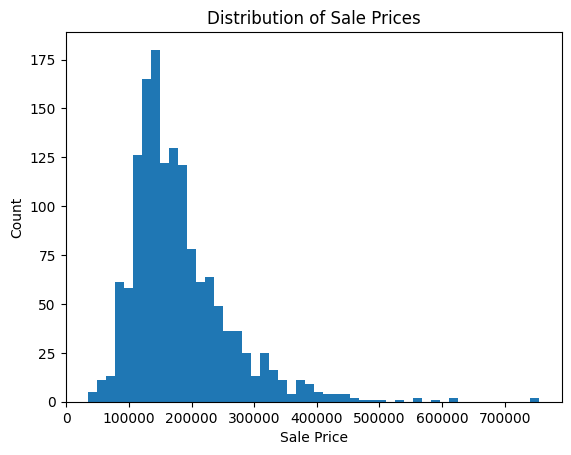

In [7]:
print(train['SalePrice'].describe())
plt.hist(train['SalePrice'], bins=50)
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.title('Distribution of Sale Prices')
plt.show()

In [9]:
y = train['SalePrice']
X = train.drop('SalePrice', axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [10]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numericals columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numericals columns: 37
Categorical columns: 43


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

# Numerical preprocessing
numerical_transformer = SimpleImputer(strategy='mean')

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle both
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Final pipeline with model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=0))
])

print("Pipeline rebuilt successfully")

Pipeline rebuilt successfully


In [12]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']
X=X.drop(cols_to_drop, axis=1)

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

print("Remaining features:", X.shape[1])
print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Remaining features: 75
Numerical: 37
Categorical: 38


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    train_size=0.8, 
    test_size=0.2, 
    random_state=0
)

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_valid)

mae = mean_absolute_error(y_valid, predictions)
print("MAE:", mae)
print(f"Average error: ${mae:,.0f}")


MAE: 17693.46616438356
Average error: $17,693


In [20]:
from xgboost import XGBRegressor

X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_valid_transformed = preprocessor.transform(X_valid)

xgb_model = XGBRegressor(
    n_estimator = 1000,
    learning_rate = 0.05,
    early_stopping_rounds = 50,
    random_state = 0,
    verbose = False
)
xgb_model.fit(
    X_train_transformed, y_train,
    eval_set=[(X_valid_transformed, y_valid)],
    verbose = False
)

# Predict and measure
xgb_predictions = xgb_model.predict(X_valid_transformed)
xgb_mae = mean_absolute_error(y_valid, xgb_predictions)
print("XGBoost MAE:", xgb_mae)
print(f"Average error: ${xgb_mae:,.0f}")

c:\Users\aarek\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\callback.py:385: UserWarning: [10:35:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator", "verbose" } are not used.

  self.starting_round = model.num_boosted_rounds()


XGBoost MAE: 16414.576171875
Average error: $16,415


In [21]:
print("Model Comparison:")
print(f"Random Forest MAE: ${mae:,.0f}")
print(f"XGBoost MAE:       ${xgb_mae:,.0f}")
print(f"XGBoost is better by: ${mae - xgb_mae:,.0f}")

Model Comparison:
Random Forest MAE: $17,693
XGBoost MAE:       $16,415
XGBoost is better by: $1,279


In [22]:
test = pd.read_csv('test.csv')

test = test.drop(cols_to_drop, axis = 1)

test_transformed = preprocessor.transform(test)

test_predictions = xgb_model.predict(test_transformed)

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index = False)
print("Submission file created sucessfully")
print(submission.head())

Submission file created sucessfully
     Id      SalePrice
0  1461  127291.359375
1  1462  147631.265625
2  1463  178925.234375
3  1464  189038.140625
4  1465  196268.890625
